# 苏州人口网格空间自相关分析实验

本实验使用苏州市人口网格面数据，参考空间自相关分析的固定流程，完成以下内容：

1. 探索性数据分析（EDA）
2. 空间权重矩阵构建与诊断
3. Global Moran's I 全局空间自相关检验
4. LISA 局部空间自相关分析
5. Getis-Ord Gi* 热点分析
6. 稳健性检验（不同权重 + 原始人口与对数人口对比）

---
**核心研究问题**

1. 苏州市人口网格是否存在显著空间自相关？
2. 哪些区域形成了高值集聚和低值集聚？
3. 结论对权重矩阵和变量变换是否敏感？


In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats

from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = Path('data/pop_grid_320500.gpkg')
OUTPUT_DIR = Path('.')
ANALYSIS_FIELD = 'population'
ANALYSIS_LABEL = '人口数量'
LOG_FIELD = 'population_log'
PERMUTATIONS = 99
ALPHA = 0.05

print('=' * 70)
print('苏州人口网格空间自相关分析')
print('=' * 70)
print(f'数据路径: {DATA_PATH.resolve()}')
print(f'输出目录: {OUTPUT_DIR.resolve()}')
print(f'排列检验次数: {PERMUTATIONS}')


苏州人口网格空间自相关分析
数据路径: D:\yan2-exercise\spatial_analysis\Homework\2\data\pop_grid_320500.gpkg
输出目录: D:\yan2-exercise\spatial_analysis\Homework\2
排列检验次数: 99


## 一、数据准备

这里直接读取苏州市人口网格数据。因为本案例是规则网格面数据，所以很适合套用 Moran's I、LISA 和 Gi* 流程。


In [2]:
gdf = gpd.read_file(DATA_PATH)
gdf = gdf.reset_index(drop=True)
gdf[ANALYSIS_FIELD] = gdf[ANALYSIS_FIELD].astype(float)
gdf[LOG_FIELD] = np.log1p(gdf[ANALYSIS_FIELD])

print('[1] 数据读取完成')
print(f'    记录数: {len(gdf)}')
print(f'    CRS: {gdf.crs}')
print(f'    几何类型: {gdf.geom_type.unique().tolist()}')
print(f'    字段: {gdf.columns.tolist()}')
print(f'    缺失值数量: {gdf[ANALYSIS_FIELD].isna().sum()}')
print(f'    重复几何数量: {gdf.geometry.duplicated().sum()}')
print(f'    边界范围: {gdf.total_bounds}')

w_queen_full = Queen.from_dataframe(gdf, use_index=False)
queen_islands = list(w_queen_full.islands)
print(f'    Queen 孤岛网格数: {len(queen_islands)}')
if queen_islands:
    print(f'    孤岛示例索引: {queen_islands[:10]}')


[1] 数据读取完成
    记录数: 9355
    CRS: EPSG:32651
    几何类型: ['Polygon']
    字段: ['population', 'geometry', 'population_log']
    缺失值数量: 0
    重复几何数量: 0
    边界范围: [ 205272.6193519  3405472.95627026  343410.29928208 3547842.51060152]


    Queen 孤岛网格数: 15
    孤岛示例索引: [22, 101, 102, 888, 1202, 1242, 1496, 2461, 5194, 7102]


In [3]:
# 为了让 Queen、LISA、Gi* 都基于同一份可比较的数据，这里剔除 Queen 下的孤岛网格。
if queen_islands:
    gdf_analysis = gdf.drop(index=queen_islands).copy().reset_index(drop=True)
else:
    gdf_analysis = gdf.copy().reset_index(drop=True)

gdf_analysis[LOG_FIELD] = np.log1p(gdf_analysis[ANALYSIS_FIELD])

y_values = gdf_analysis[ANALYSIS_FIELD].to_numpy(dtype=float)
y_log_values = gdf_analysis[LOG_FIELD].to_numpy(dtype=float)

print('[2] 构建分析样本')
print(f'    原始网格数: {len(gdf)}')
print(f'    有效网格数: {len(gdf_analysis)}')
print(f'    剔除孤岛数: {len(gdf) - len(gdf_analysis)}')
print(f'    原始人口偏度: {stats.skew(gdf[ANALYSIS_FIELD]):.4f}')
print(f'    有效样本人口偏度: {stats.skew(y_values):.4f}')
print(f'    对数人口偏度: {stats.skew(y_log_values):.4f}')


[2] 构建分析样本
    原始网格数: 9355
    有效网格数: 9340
    剔除孤岛数: 15
    原始人口偏度: 5.5305
    有效样本人口偏度: 5.5298
    对数人口偏度: -1.2005


从偏度可以看到，原始人口分布右偏很明显，所以正文先用原始人口做分析，后面再补一个 `log1p(population)` 的稳健性比较。

## 二、EDA：人口分布与空间分布

In [4]:
print('=' * 70)
print('步骤一：探索性数据分析（EDA）')
print('=' * 70)

summary = pd.Series({
    '样本量': len(y_values),
    '均值': np.mean(y_values),
    '中位数': np.median(y_values),
    '标准差': np.std(y_values),
    '最小值': np.min(y_values),
    '最大值': np.max(y_values),
    '偏度': stats.skew(y_values),
    '峰度': stats.kurtosis(y_values),
})
print(summary.round(4))


步骤一：探索性数据分析（EDA）
样本量     9340.0000
均值      1207.3505
中位数      718.0000
标准差     1662.5294
最小值        1.0000
最大值    24184.0000
偏度         5.5298
峰度        47.4780
dtype: float64


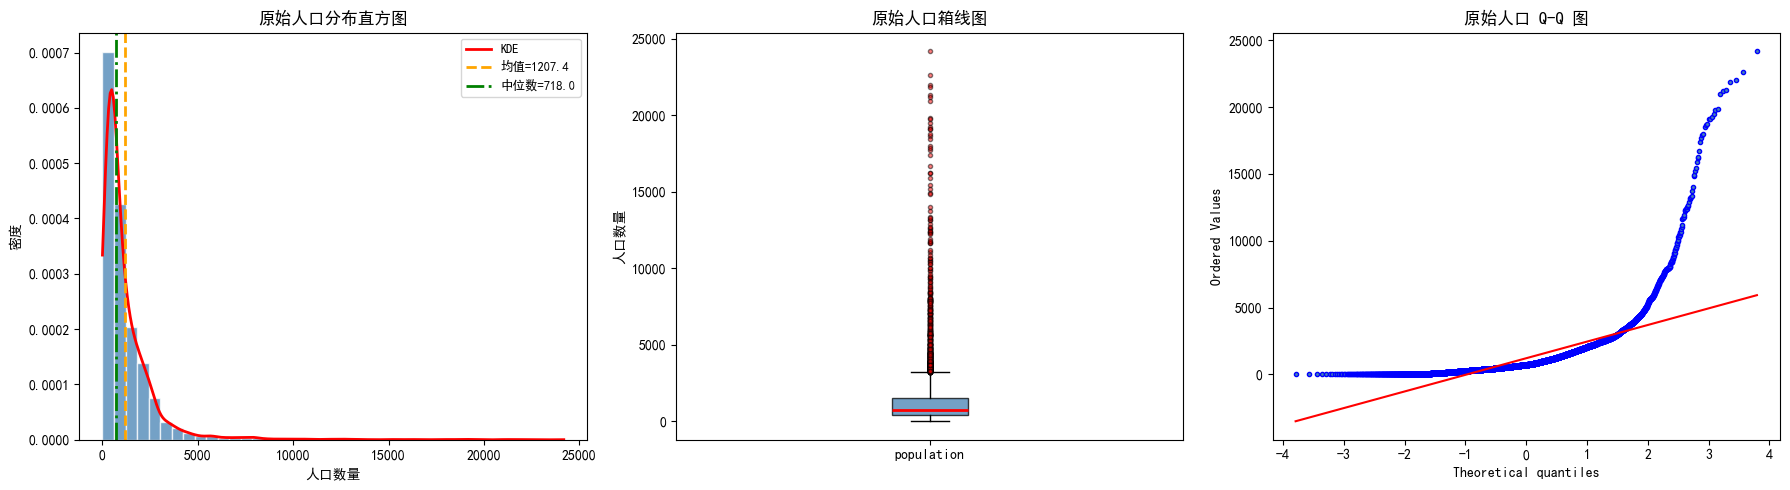

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 直方图 + KDE
axes[0].hist(y_values, bins=40, density=True, alpha=0.75, color='steelblue', edgecolor='white')
kde_x = np.linspace(y_values.min(), y_values.max(), 300)
kde = stats.gaussian_kde(y_values)
axes[0].plot(kde_x, kde(kde_x), color='red', linewidth=2, label='KDE')
axes[0].axvline(np.mean(y_values), color='orange', linestyle='--', linewidth=2, label=f'均值={np.mean(y_values):.1f}')
axes[0].axvline(np.median(y_values), color='green', linestyle='-.', linewidth=2, label=f'中位数={np.median(y_values):.1f}')
axes[0].set_title('原始人口分布直方图')
axes[0].set_xlabel(ANALYSIS_LABEL)
axes[0].set_ylabel('密度')
axes[0].legend(fontsize=9)

# 箱线图
axes[1].boxplot(
    y_values,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.75),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5),
)
axes[1].set_title('原始人口箱线图')
axes[1].set_ylabel(ANALYSIS_LABEL)
axes[1].set_xticklabels(['population'])

# QQ 图
stats.probplot(y_values, plot=axes[2])
axes[2].set_title('原始人口 Q-Q 图')
axes[2].get_lines()[0].set_markerfacecolor('steelblue')
axes[2].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'output_01_eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


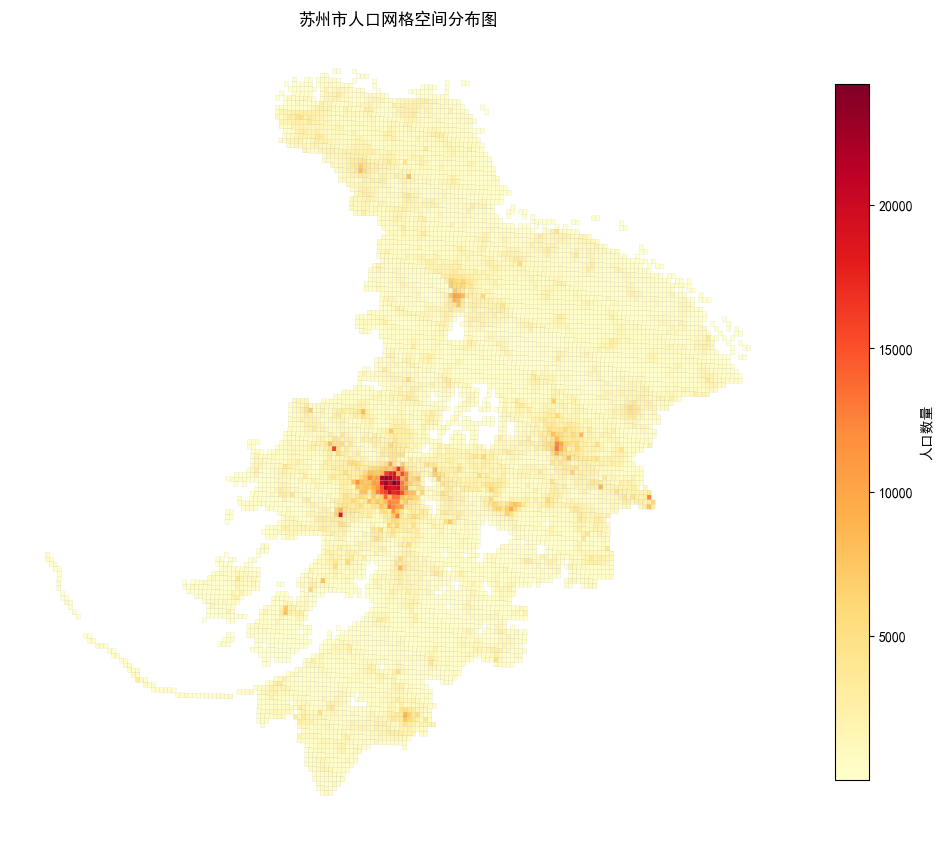

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
gdf_analysis.plot(
    column=ANALYSIS_FIELD,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': '人口数量', 'shrink': 0.8},
    linewidth=0.05,
    edgecolor='gray',
    ax=ax,
)
ax.set_title('苏州市人口网格空间分布图')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'output_02_spatial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 三、空间权重矩阵构建与诊断

采用三种权重方案：

- `Queen`：主方案
- `KNN(4)`：稳健性方案
- `KNN(8)`：稳健性方案


In [7]:
print('=' * 70)
print('步骤二：空间权重矩阵构建与选择')
print('=' * 70)

w_queen = Queen.from_dataframe(gdf_analysis, use_index=False)
w_queen.transform = 'r'

w_knn4 = KNN.from_dataframe(gdf_analysis, k=4)
w_knn4.transform = 'r'

w_knn8 = KNN.from_dataframe(gdf_analysis, k=8)
w_knn8.transform = 'r'

weight_schemes = {
    'Queen': w_queen,
    'KNN(4)': w_knn4,
    'KNN(8)': w_knn8,
}

for name, w in weight_schemes.items():
    neighbor_counts = np.array([len(w.neighbors[i]) for i in w.id_order])
    print(f'[{name}]')
    print(f'  单元数: {w.n}')
    print(f'  平均邻居数: {neighbor_counts.mean():.2f}')
    print(f'  最小邻居数: {neighbor_counts.min()}')
    print(f'  最大邻居数: {neighbor_counts.max()}')
    print(f'  孤岛数: {len(getattr(w, "islands", []))}')


步骤二：空间权重矩阵构建与选择


[Queen]
  单元数: 9340
  平均邻居数: 7.53
  最小邻居数: 1
  最大邻居数: 8
  孤岛数: 0
[KNN(4)]
  单元数: 9340
  平均邻居数: 4.00
  最小邻居数: 4
  最大邻居数: 4
  孤岛数: 0
[KNN(8)]
  单元数: 9340
  平均邻居数: 8.00
  最小邻居数: 8
  最大邻居数: 8
  孤岛数: 0


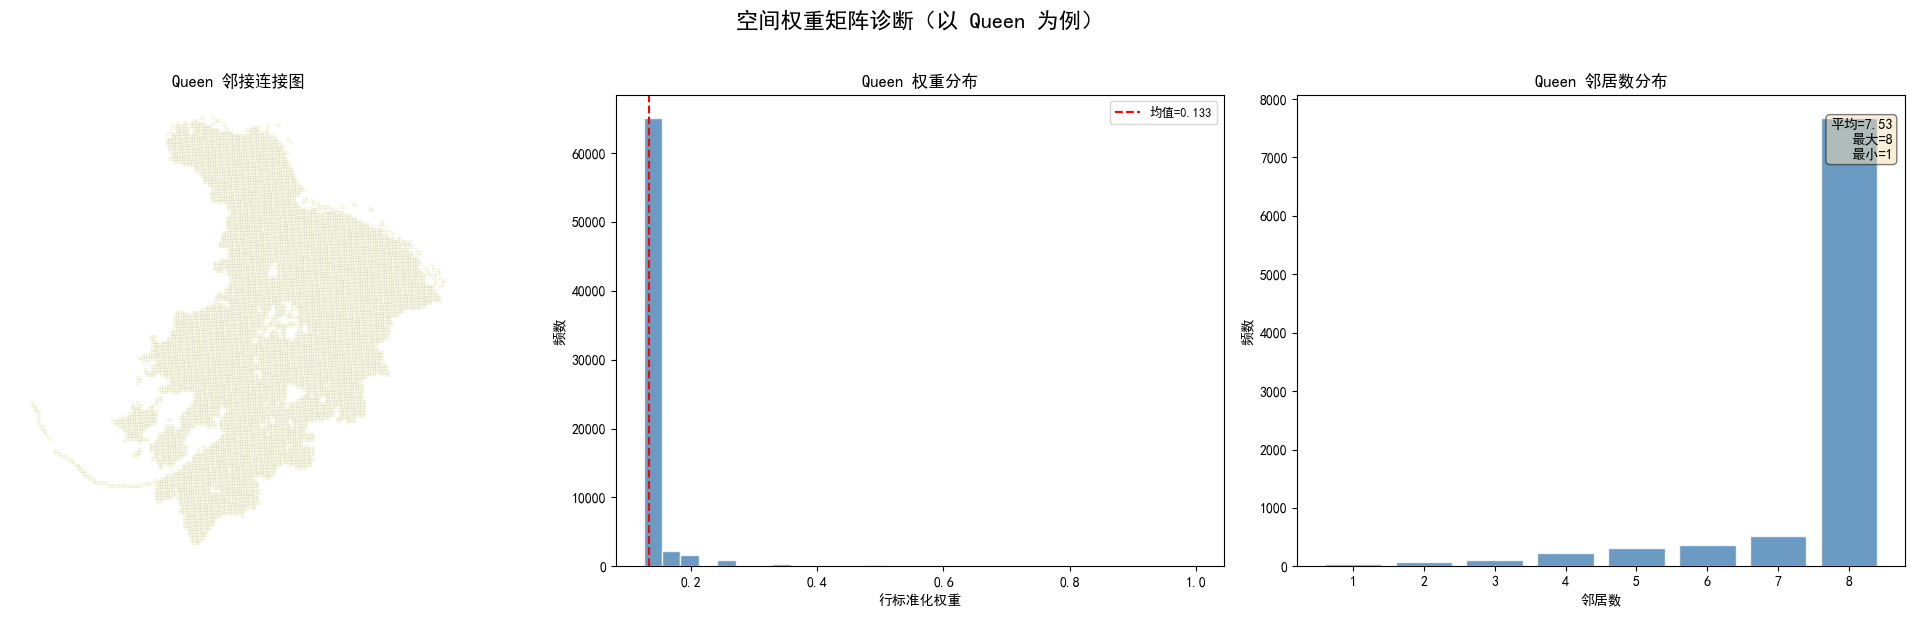

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('空间权重矩阵诊断（以 Queen 为例）', fontsize=16, y=1.02)

w_demo = w_queen
centroids = gdf_analysis.geometry.centroid
coords = list(zip(centroids.x, centroids.y))

# 连接图
ax = axes[0]
gdf_analysis.plot(ax=ax, facecolor='lightyellow', edgecolor='gray', linewidth=0.05)
for i, neighbors in w_demo.neighbors.items():
    xi, yi = coords[i]
    for j in neighbors:
        xj, yj = coords[j]
        ax.plot([xi, xj], [yi, yj], color='blue', alpha=0.03, linewidth=0.15)
ax.set_title('Queen 邻接连接图')
ax.set_axis_off()

# 权重分布
ax = axes[1]
all_weights = []
for i in w_demo.id_order:
    all_weights.extend(w_demo.weights[i])
ax.hist(all_weights, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(all_weights), color='red', linestyle='--', label=f'均值={np.mean(all_weights):.3f}')
ax.set_title('Queen 权重分布')
ax.set_xlabel('行标准化权重')
ax.set_ylabel('频数')
ax.legend(fontsize=9)

# 邻居数分布
ax = axes[2]
neighbor_counts = [len(w_demo.neighbors[i]) for i in w_demo.id_order]
values, counts = np.unique(neighbor_counts, return_counts=True)
ax.bar(values.astype(str), counts, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Queen 邻居数分布')
ax.set_xlabel('邻居数')
ax.set_ylabel('频数')
ax.text(
    0.98,
    0.95,
    f'平均={np.mean(neighbor_counts):.2f}\n最大={np.max(neighbor_counts)}\n最小={np.min(neighbor_counts)}',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'output_03_weight_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


## 四、Global Moran's I

In [9]:
print('=' * 70)
print("步骤三：Global Moran's I 全局空间自相关检验")
print('=' * 70)

moran_results = {}
for name, w in weight_schemes.items():
    moran = Moran(y_values, w, permutations=PERMUTATIONS)
    moran_results[name] = moran
    print(f'[{name}]')
    print(f"  Moran's I = {moran.I:.4f}")
    print(f'  E[I] = {moran.EI:.6f}')
    print(f'  Z值 = {moran.z_norm:.4f}')
    print(f'  p值(正态) = {moran.p_norm:.6f}')
    print(f'  p值(排列) = {moran.p_sim:.6f}')


步骤三：Global Moran's I 全局空间自相关检验
[Queen]
  Moran's I = 0.7689
  E[I] = -0.000107
  Z值 = 140.1834
  p值(正态) = 0.000000
  p值(排列) = 0.010000
[KNN(4)]
  Moran's I = 0.7966
  E[I] = -0.000107
  Z值 = 109.8661
  p值(正态) = 0.000000
  p值(排列) = 0.010000
[KNN(8)]
  Moran's I = 0.7665
  E[I] = -0.000107
  Z值 = 149.6130
  p值(正态) = 0.000000
  p值(排列) = 0.010000


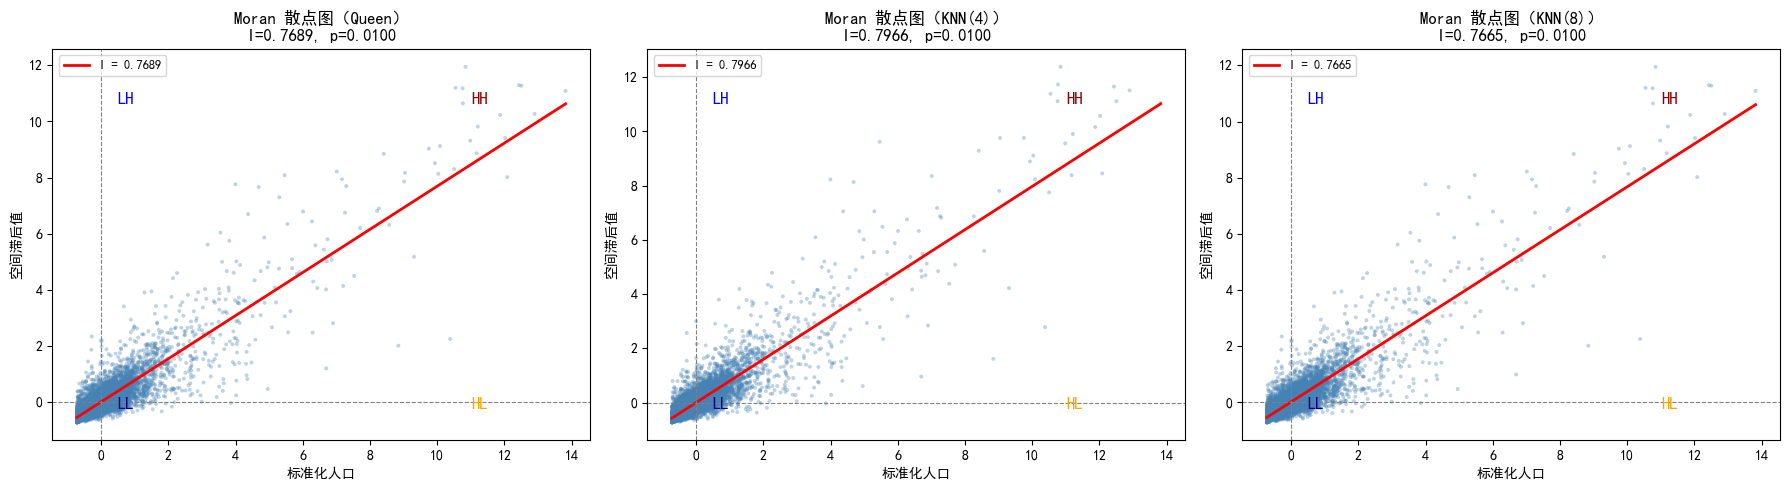

In [10]:
fig, axes = plt.subplots(1, len(moran_results), figsize=(6 * len(moran_results), 5))
if len(moran_results) == 1:
    axes = [axes]

y_std = (y_values - y_values.mean()) / y_values.std()

for ax, (name, moran) in zip(axes, moran_results.items()):
    w = weight_schemes[name]
    lag = w.sparse.dot(y_std)
    ax.scatter(y_std, lag, s=8, alpha=0.35, c='steelblue', edgecolors='none')
    fit = np.polyfit(y_std, lag, 1)
    x_line = np.linspace(y_std.min(), y_std.max(), 200)
    ax.plot(x_line, np.polyval(fit, x_line), color='red', linewidth=2, label=f"I = {moran.I:.4f}")
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.text(0.78, 0.86, 'HH', transform=ax.transAxes, color='darkred', fontsize=12, fontweight='bold')
    ax.text(0.12, 0.86, 'LH', transform=ax.transAxes, color='blue', fontsize=12, fontweight='bold')
    ax.text(0.12, 0.08, 'LL', transform=ax.transAxes, color='darkblue', fontsize=12, fontweight='bold')
    ax.text(0.78, 0.08, 'HL', transform=ax.transAxes, color='orange', fontsize=12, fontweight='bold')
    ax.set_title(f"Moran 散点图（{name}）\nI={moran.I:.4f}, p={moran.p_sim:.4f}")
    ax.set_xlabel('标准化人口')
    ax.set_ylabel('空间滞后值')
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'output_04_moran_scatterplot.png', dpi=150, bbox_inches='tight')
plt.show()


## 五、LISA 局部空间自相关分析

In [11]:
print('=' * 70)
print('步骤四：LISA 局部空间自相关分析')
print('=' * 70)

primary_w_name = 'Queen'
primary_w = weight_schemes[primary_w_name]

lisa = Moran_Local(y_values, primary_w, permutations=PERMUTATIONS)
labels = lisa.q
significant = lisa.p_sim <= ALPHA

lisa_class = np.zeros(len(y_values), dtype=int)
lisa_class[significant & (labels == 1)] = 1  # HH
lisa_class[significant & (labels == 2)] = 2  # LH
lisa_class[significant & (labels == 3)] = 3  # LL
lisa_class[significant & (labels == 4)] = 4  # HL

class_names = {
    0: '不显著',
    1: 'HH（高-高）',
    2: 'LH（低-高）',
    3: 'LL（低-低）',
    4: 'HL（高-低）',
}

for key in [1, 3, 2, 4, 0]:
    count = int((lisa_class == key).sum())
    pct = count / len(lisa_class) * 100
    print(f'{class_names[key]}: {count} 个网格 ({pct:.2f}%)')


步骤四：LISA 局部空间自相关分析


HH（高-高）: 558 个网格 (5.97%)
LL（低-低）: 2311 个网格 (24.74%)
LH（低-高）: 10 个网格 (0.11%)
HL（高-低）: 22 个网格 (0.24%)
不显著: 6439 个网格 (68.94%)


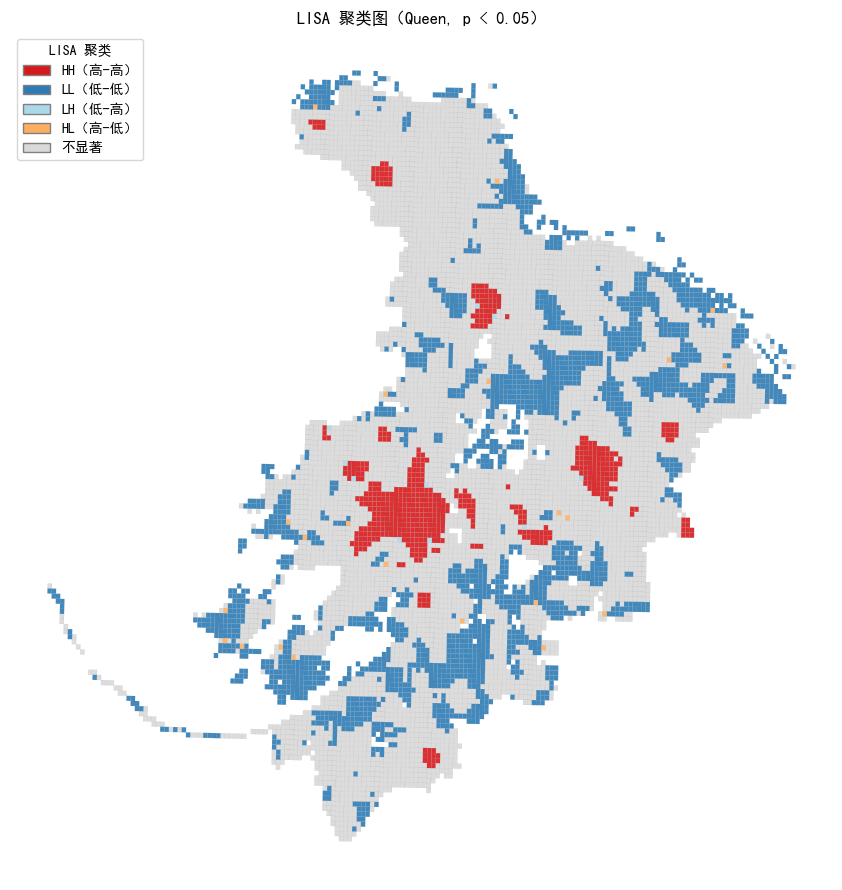

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
colors = {
    0: '#d9d9d9',
    1: '#d7191c',
    2: '#abd9e9',
    3: '#2c7bb6',
    4: '#fdae61',
}

gdf_lisa = gdf_analysis.copy()
gdf_lisa['lisa_class'] = lisa_class

for cls in [0, 1, 2, 3, 4]:
    mask = gdf_lisa['lisa_class'] == cls
    if mask.any():
        gdf_lisa[mask].plot(
            ax=ax,
            facecolor=colors[cls],
            edgecolor='gray',
            linewidth=0.05,
            alpha=0.9,
        )

legend_elements = [
    Patch(facecolor=colors[c], edgecolor='gray', label=class_names[c])
    for c in [1, 3, 2, 4, 0]
    if (lisa_class == c).sum() > 0
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, title='LISA 聚类')
ax.set_title('LISA 聚类图（Queen, p < 0.05）')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'output_05_lisa_cluster.png', dpi=150, bbox_inches='tight')
plt.show()


## 六、Getis-Ord Gi* 热点分析

In [13]:
print('=' * 70)
print('步骤五：Getis-Ord Gi* 热点分析')
print('=' * 70)

gi_star = G_Local(y_values, primary_w, transform='B', star=True, permutations=PERMUTATIONS)
gi_z = np.nan_to_num(gi_star.Zs, nan=0.0)
gi_p = np.nan_to_num(gi_star.p_sim, nan=1.0)

hot_99 = int(((gi_z > 0) & (gi_p < 0.01)).sum())
hot_95 = int(((gi_z > 0) & (gi_p >= 0.01) & (gi_p < 0.05)).sum())
hot_90 = int(((gi_z > 0) & (gi_p >= 0.05) & (gi_p < 0.10)).sum())
cold_99 = int(((gi_z < 0) & (gi_p < 0.01)).sum())
cold_95 = int(((gi_z < 0) & (gi_p >= 0.01) & (gi_p < 0.05)).sum())
cold_90 = int(((gi_z < 0) & (gi_p >= 0.05) & (gi_p < 0.10)).sum())
not_sig = int((gi_p >= 0.10).sum())

print(f'Gi* Z值范围: [{gi_z.min():.4f}, {gi_z.max():.4f}]')
print(f'热点(99%): {hot_99}')
print(f'热点(95%): {hot_95}')
print(f'热点(90%): {hot_90}')
print(f'冷点(99%): {cold_99}')
print(f'冷点(95%): {cold_95}')
print(f'冷点(90%): {cold_90}')
print(f'不显著: {not_sig}')


步骤五：Getis-Ord Gi* 热点分析


Gi* Z值范围: [-2.1697, 35.4942]
热点(99%): 0
热点(95%): 1042
热点(90%): 513
冷点(99%): 0
冷点(95%): 1744
冷点(90%): 1084
不显著: 4957


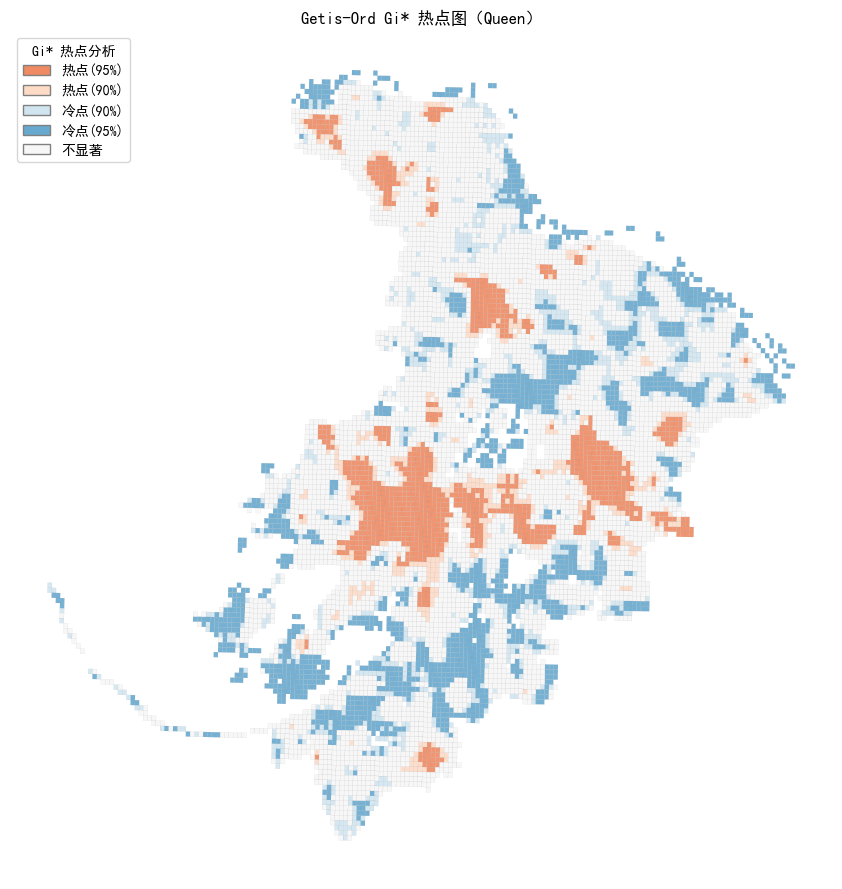

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 9))

gi_class = np.zeros(len(y_values), dtype=int)
gi_class[(gi_z > 0) & (gi_p < 0.01)] = 3
gi_class[(gi_z > 0) & (gi_p >= 0.01) & (gi_p < 0.05)] = 2
gi_class[(gi_z > 0) & (gi_p >= 0.05) & (gi_p < 0.10)] = 1
gi_class[(gi_z < 0) & (gi_p < 0.01)] = -3
gi_class[(gi_z < 0) & (gi_p >= 0.01) & (gi_p < 0.05)] = -2
gi_class[(gi_z < 0) & (gi_p >= 0.05) & (gi_p < 0.10)] = -1

gi_colors = {
    -3: '#2166ac',
    -2: '#67a9cf',
    -1: '#d1e5f0',
     0: '#f7f7f7',
     1: '#fddbc7',
     2: '#ef8a62',
     3: '#b2182b',
}

gi_labels = {
    -3: '冷点(99%)',
    -2: '冷点(95%)',
    -1: '冷点(90%)',
     0: '不显著',
     1: '热点(90%)',
     2: '热点(95%)',
     3: '热点(99%)',
}

gdf_gi = gdf_analysis.copy()
gdf_gi['gi_class'] = gi_class
for cls in [3, 2, 1, -1, -2, -3, 0]:
    mask = gdf_gi['gi_class'] == cls
    if mask.any():
        gdf_gi[mask].plot(ax=ax, facecolor=gi_colors[cls], edgecolor='gray', linewidth=0.05, alpha=0.9)

legend_elements = [
    Patch(facecolor=gi_colors[c], edgecolor='gray', label=gi_labels[c])
    for c in [3, 2, 1, -1, -2, -3, 0]
    if (gi_class == c).sum() > 0
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, title='Gi* 热点分析')
ax.set_title('Getis-Ord Gi* 热点图（Queen）')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'output_06_gistar_hotspot.png', dpi=150, bbox_inches='tight')
plt.show()


## 七、稳健性检验

这里做两类稳健性：

1. 不同权重矩阵（`Queen`、`KNN(4)`、`KNN(8)`）
2. 原始人口 vs 对数人口 `log1p(population)`


In [15]:
print('=' * 70)
print('步骤六：稳健性检验')
print('=' * 70)

print('【1】不同权重下的 Global Moran\'s I 对比')
print(f"{'权重方案':<10} {'Moran I':>10} {'Z值':>10} {'p值(排列)':>12}")
print('-' * 46)
for name, moran in moran_results.items():
    print(f"{name:<10} {moran.I:>10.4f} {moran.z_norm:>10.4f} {moran.p_sim:>12.6f}")


步骤六：稳健性检验
【1】不同权重下的 Global Moran's I 对比
权重方案          Moran I         Z值       p值(排列)
----------------------------------------------
Queen          0.7689   140.1834     0.010000
KNN(4)         0.7966   109.8661     0.010000
KNN(8)         0.7665   149.6130     0.010000


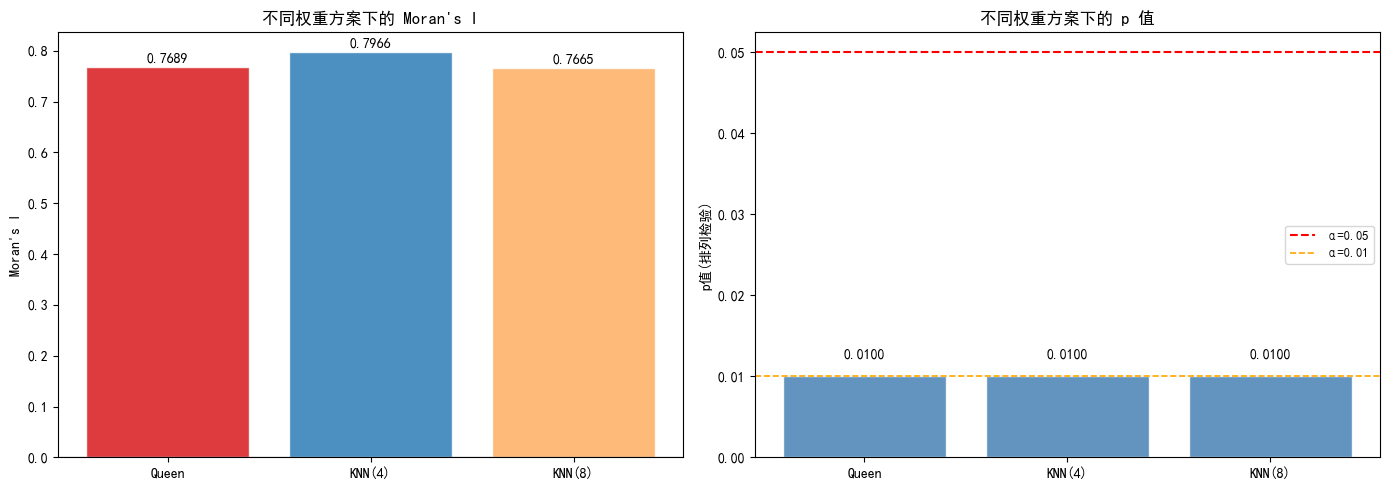

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(moran_results.keys())
i_values = [moran_results[n].I for n in names]
p_values = [moran_results[n].p_sim for n in names]

bars = axes[0].bar(names, i_values, color=['#d7191c', '#2c7bb6', '#fdae61'], edgecolor='white', alpha=0.85)
axes[0].axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, i_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=10)
axes[0].set_title("不同权重方案下的 Moran's I")
axes[0].set_ylabel("Moran's I")

axes[1].bar(names, p_values, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='α=0.05')
axes[1].axhline(0.01, color='orange', linestyle='--', linewidth=1.2, label='α=0.01')
for idx, val in enumerate(p_values):
    axes[1].text(idx, val + 0.002, f'{val:.4f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('不同权重方案下的 p 值')
axes[1].set_ylabel('p值(排列检验)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'output_07_robustness.png', dpi=150, bbox_inches='tight')
plt.show()


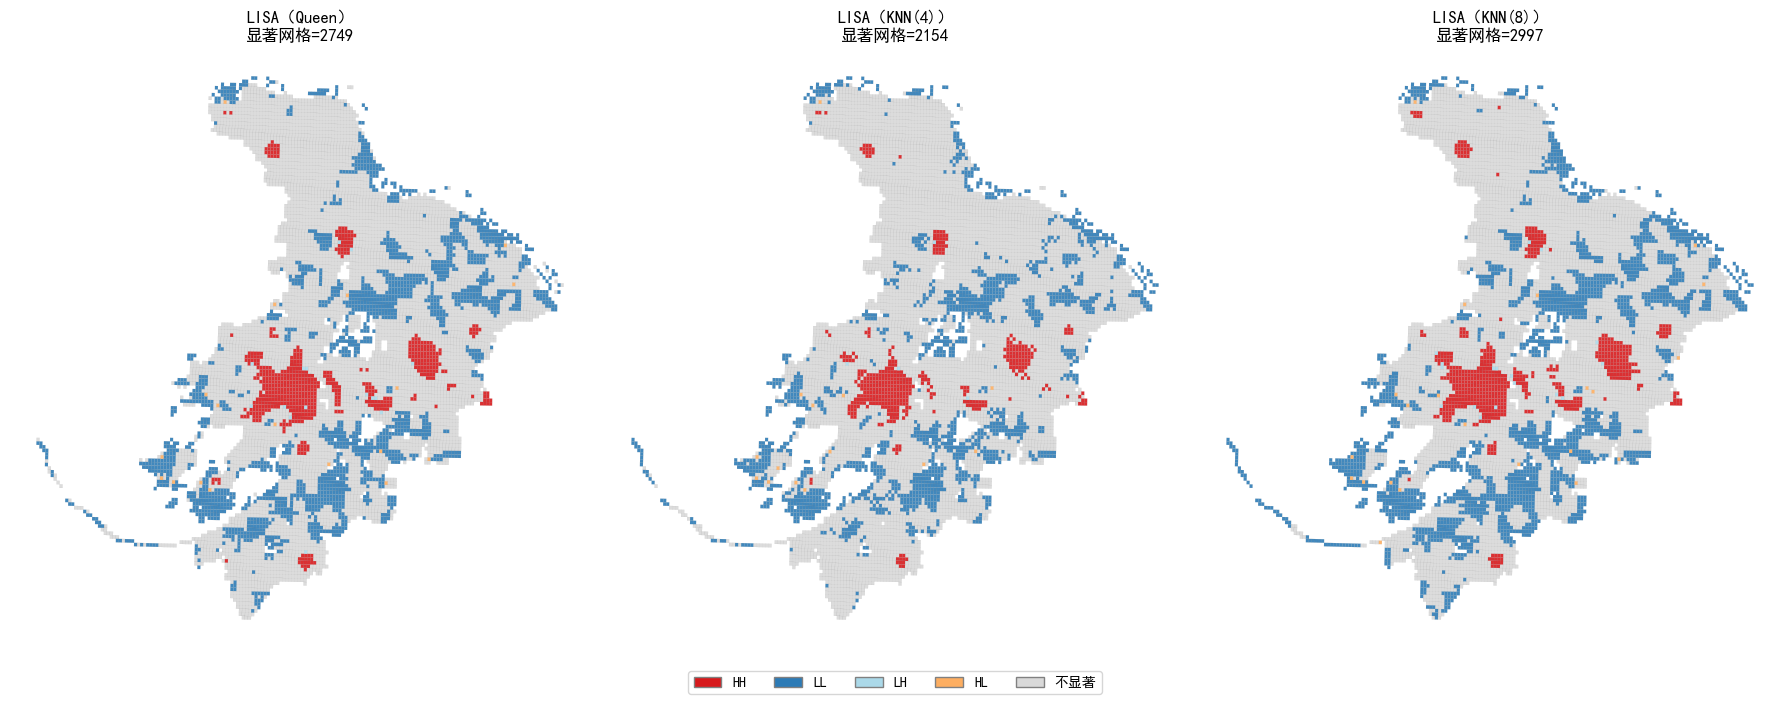

In [17]:
n_schemes = len(weight_schemes)
fig, axes = plt.subplots(1, n_schemes, figsize=(6 * n_schemes, 7))
if n_schemes == 1:
    axes = [axes]

lisa_colors = {0: '#d9d9d9', 1: '#d7191c', 2: '#abd9e9', 3: '#2c7bb6', 4: '#fdae61'}
lisa_labels = {0: '不显著', 1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}

for ax, (name, w) in zip(axes, weight_schemes.items()):
    lisa_w = Moran_Local(y_values, w, permutations=PERMUTATIONS)
    labels_w = lisa_w.q
    sig_w = lisa_w.p_sim <= ALPHA
    class_w = np.zeros(len(y_values), dtype=int)
    class_w[sig_w & (labels_w == 1)] = 1
    class_w[sig_w & (labels_w == 2)] = 2
    class_w[sig_w & (labels_w == 3)] = 3
    class_w[sig_w & (labels_w == 4)] = 4

    gdf_tmp = gdf_analysis.copy()
    gdf_tmp['lisa_class'] = class_w
    for cls in [0, 1, 2, 3, 4]:
        mask = gdf_tmp['lisa_class'] == cls
        if mask.any():
            gdf_tmp[mask].plot(ax=ax, facecolor=lisa_colors[cls], edgecolor='gray', linewidth=0.05, alpha=0.9)
    ax.set_title(f'LISA（{name}）\n显著网格={(class_w > 0).sum()}')
    ax.set_axis_off()

legend_handles = [Patch(facecolor=lisa_colors[c], edgecolor='gray', label=lisa_labels[c]) for c in [1, 3, 2, 4, 0]]
fig.legend(handles=legend_handles, loc='lower center', ncol=5, fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'output_08_lisa_robustness.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
log_moran_results = {}
for name, w in weight_schemes.items():
    log_moran_results[name] = Moran(y_log_values, w, permutations=PERMUTATIONS)

comparison_df = pd.DataFrame({
    'weight': list(weight_schemes.keys()),
    'I_raw': [moran_results[name].I for name in weight_schemes.keys()],
    'p_raw': [moran_results[name].p_sim for name in weight_schemes.keys()],
    'I_log': [log_moran_results[name].I for name in weight_schemes.keys()],
    'p_log': [log_moran_results[name].p_sim for name in weight_schemes.keys()],
})
comparison_df


,weight,I_raw,p_raw,I_log,p_log
0,Queen,0.768850,0.01,0.653281,0.01
1,KNN(4),0.796566,0.01,0.677092,0.01
2,KNN(8),0.766513,0.01,0.619948,0.01


上表用于比较原始人口和对数人口的 Moran's I。如果两套结果方向一致、显著性一致，就可以说明结论比较稳健。

## 八、结果小结

- 如果 Moran's I 显著为正，说明人口网格存在明显空间集聚。
- LISA 图重点看 `HH` 和 `LL`，分别对应高人口集聚区和低人口集聚区。
- Gi* 图更适合从“热点/冷点”角度概括空间格局。
- 如果不同权重、原始人口和对数人口的结果方向一致，就可以说本实验结论具有稳健性。
